# **BANK CUSTOMER CHURN DATASET**

## **PROJECT REQUIREMENTS**

### **Business Understanding**

***1. Business Problem***

Banks are experiencing customer churn, where customers stop using their services or close their accounts. This leads to:
* Loss of revenue
* Increased cost of acquiring new customers
* Reduced long-term profitability

The bank wants to understand:
* Why customers are leaving
* Which customers are most likely to churn
* How to improve customer retention

***2. Industry / Domain***

Banking and Financial Services Industry
>This dataset belongs to the banking sector and includes customer demographics, account details, and behavior patterns used to analyze churn.

***3. Project Objective***
>The main objective of this project is to analyze customer data and identify key factors responsible for customer churn in the bank.

*Sub-objectives:*
* Identify high-risk customers likely to churn
* Understand patterns in customer behavior.
* Find relationships between features and churn.
* Improve customer retention strategies.
* Reduce churn rate and increase profitability.

***4. KPI's***

>KPIs are measurable values used to track how well a business is performing.
In the bank churn project, KPIs help to understand customer behavior and measure how many customers are staying or leaving the bank.

*Main KPIs in This Project*
* Churn Rate → Percentage of customers leaving the bank
* Retention Rate → Percentage of customers staying
* Total Customers → Total number of bank customers
* Active Member Rate → Percentage of active customers
* Average Balance → Average money in customer accounts
* Average Credit Score → Financial health of customers
* Product Usage Rate → Average number of bank products used

In [41]:
churn_rate = (df['Exited'].mean())*100
retention_rate = 100 - churn_rate
active_rate = (df['IsActiveMember'].mean())*100
avg_balance = df['Balance'].mean()

print("Churn Rate:", churn_rate)
print("Retention Rate:", retention_rate)
print("Active Member Rate:", active_rate)
print("Average Balance:", avg_balance)

Churn Rate: 20.369999999999997
Retention Rate: 79.63
Active Member Rate: 51.51
Average Balance: 76485.889288


## Dataset Description

The Bank Customer Churn Dataset contains information about 10,000 bank customers and their account details. The dataset is used to analyze customer behavior and identify factors that influence customer churn (customers leaving the bank).

### Dataset Information
- Total Records: 10,000
- Total Features: 14
- Industry: Banking and Financial Services
- Target Variable: Exited
  - 0 = Customer Stayed
  - 1 = Customer Left the Bank

### Features Description

| Column Name | Description |
|-------------|-------------|
| RowNumber | Unique row identifier |
| CustomerId | Unique customer ID |
| Surname | Customer surname |
| CreditScore | Customer credit score |
| Geography | Customer country (France, Germany, Spain) |
| Gender | Customer gender |
| Age | Customer age |
| Tenure | Number of years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Whether customer has a credit card (1 = Yes, 0 = No) |
| IsActiveMember | Whether customer is an active member (1 = Yes, 0 = No) |
| EstimatedSalary | Estimated annual salary |
| Exited | Customer churn status (1 = Left, 0 = Stayed) |

### Purpose of the Dataset

The purpose of this dataset is to understand customer churn behavior and identify the factors that cause customers to leave the bank. By analyzing customer demographics, financial information, and account activity, the bank can develop strategies to improve customer retention and reduce churn.

### **Data Cleaning**

Data Cleaning is the process of identifying and correcting or removing errors, missing values, duplicate records, and incorrect or irrelevant data from a dataset to make it accurate and consistent for analysis.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


***1. Dataset Shape Analysis***

In [44]:
df.shape #Dataset shape helps us understand the number of rows (records) and columns (features) in the dataset. It gives an overview of dataset size.

(10000, 14)

***2. Data Type Analysis***

In [45]:
df.info() # provides a quick summary of the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [46]:
df.dtypes #Data type helps identify whether columns are numerical, categorical, or object type.

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

***3. Missing Value Analysis***

In [94]:
df.isnull() # Missing value analysis is used to check whether any data is missing in the dataset. Missing values can affect accuracy of analysis.

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [93]:
df.isnull().sum() # Counts the total missing values in each column.

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

***4. Duplicate Record Analysis***

In [49]:
df.duplicated() # It checks whether a row is a duplicate of a previous row.

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [50]:
df.duplicated().sum() # It counts the total number of duplicate rows in the dataset.

0

In [ ]:
df.drop_duplicates(inplace=True) # remove duplicate values

***5. Handling Missing Values***

If missing values are present, they can be handled by:
* Removing rows
* Filling with mean/median/mode

In [ ]:
# No missing values found in the dataset.
# Therefore no missing value treatment was required.

***6. Removing Duplicates***

In [52]:
df.drop_duplicates(inplace=True) # Removing duplicates ensures each customer appears only once in the dataset.

***7. Removing Unnecessary Columns***

In [53]:
df.drop(columns=['RowNumber'], inplace=True) # Some column like row number do not help in analysis and are removed to improve efficiency.

In [54]:
df.head() # It displays the first 5 rows of the dataset by default.

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


***8. Data Consistency Checks***

Ensure the data contains valid and realistic values before analysis.(e.g., no negative balance, valid age range).

In [60]:
# Negative Balance
df[df['Balance'] < 0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [59]:
# Valid Age Range
df[(df['Age'] < 18) | (df['Age'] > 100)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [61]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [62]:
df.describe() # It generates descriptive statistics for all numerical columns in the dataset.

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### **Exploratory Data Analysis (EDA)**
>Exploratory Data Analysis (EDA) is the process of analyzing data to understand its patterns, trends, and relationships using statistical summaries and visualizations.

It helps us:

* Understand data structure
* Find patterns and trends
* Detect anomalies

**1. Univariate Analysis**
> Analyze one variable at a time.

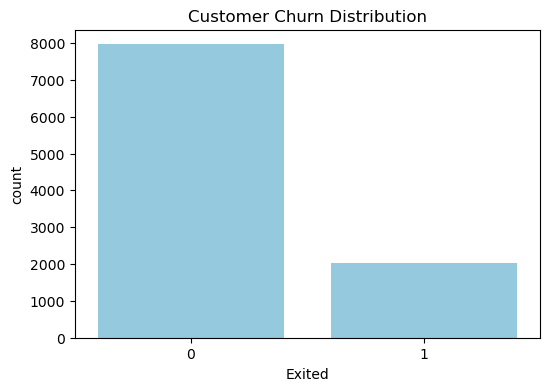

In [96]:
# A. Churn Distribution - frequency distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, color='skyblue')
plt.title('Customer Churn Distribution')
plt.show()

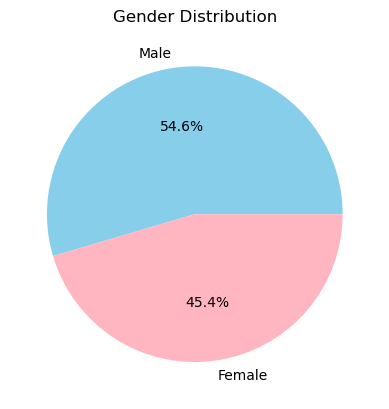

In [64]:
# B. Gender Distribution
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue', 'lightpink']
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

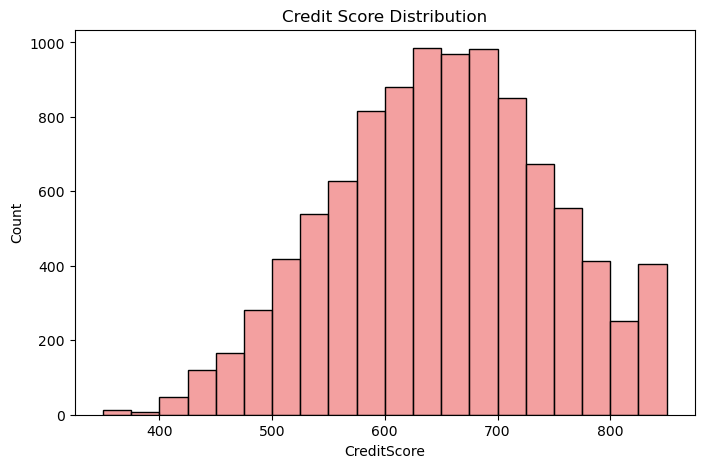

In [97]:
# C. Credit Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], bins=20, color='lightcoral') # shows distribution of numerical data by grouping values
plt.title('Credit Score Distribution')
plt.show()

**2. Bivariate Analysis**
> Analyze the relationship between two variables.

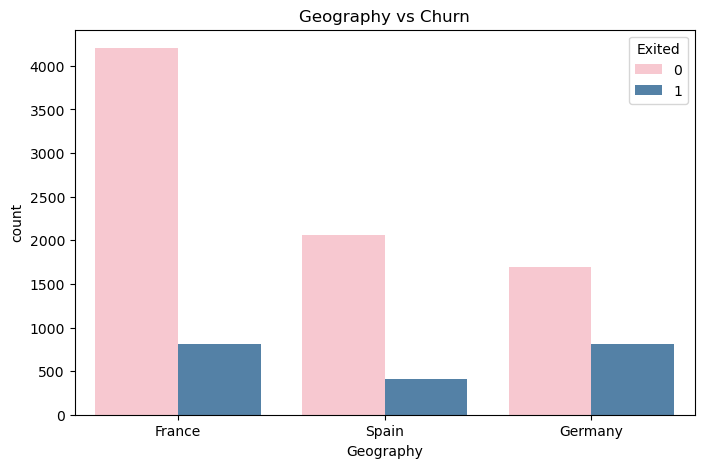

In [66]:
# A. Geography vs Churn - Churn differs across countries.
plt.figure(figsize=(8,5))
sns.countplot(
    x='Geography',
    hue='Exited',
    data=df,
    palette=['pink', 'steelblue']
)

plt.title('Geography vs Churn')
plt.show()

**3. Multivariate Analysis**
> Analyze relationships among multiple variables.

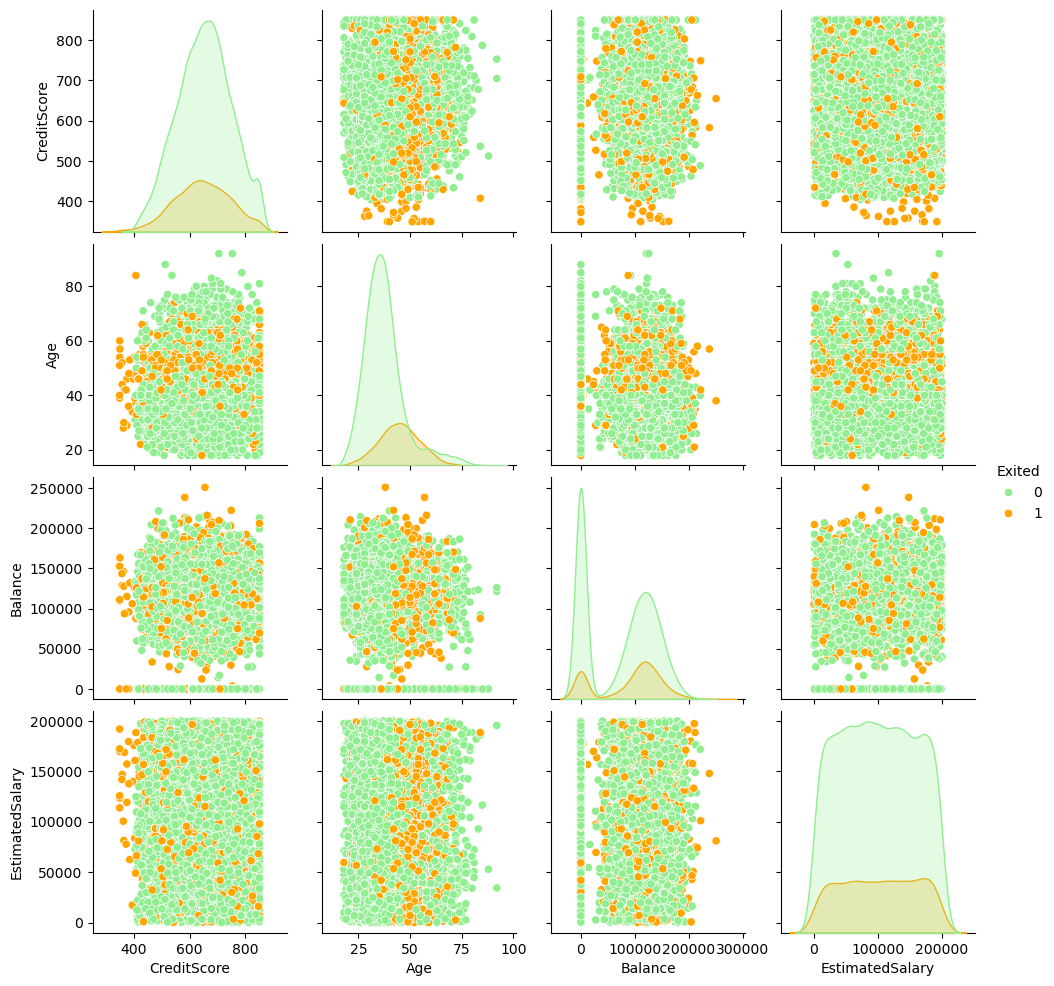

In [67]:
# A. Pair Plot - The bank should consider several factors rather than a single variable when predicting churn.
sns.pairplot(
    df[['CreditScore',
        'Age',
        'Balance',
        'EstimatedSalary',
        'Exited']],
    hue='Exited',
    palette=['lightgreen', 'orange']
)

plt.show()

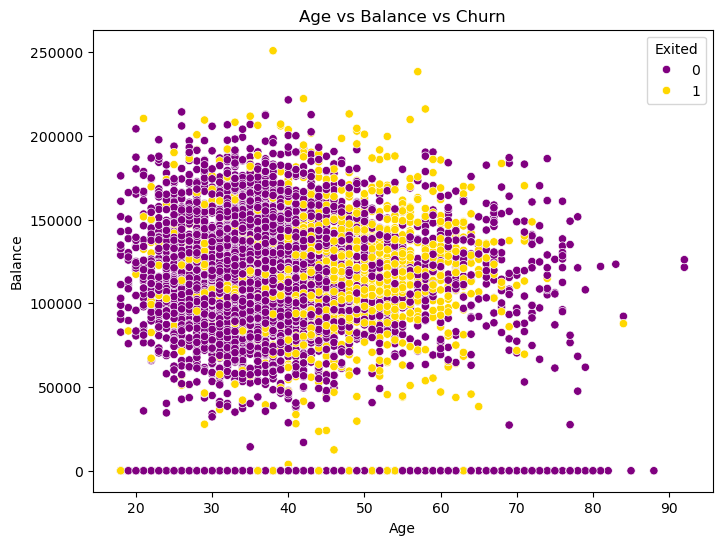

In [68]:
# B. Age, Balance and Churn - Older customers with high balances tend to churn more.
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='Balance',
    hue='Exited',
    data=df,
    palette=['purple', 'gold']
)

plt.title('Age vs Balance vs Churn')
plt.show()

### **Pivot Table Analysis**
> Create business-focused pivot tables to identify patterns and trends.

In [69]:
# 1. Geography vs Churn Rate - Customer satisfaction, competition, banking policies, or service quality may differ across regions.
pd.pivot_table(
    df,
    values='Exited',
    index='Geography',
    aggfunc='mean'
)*100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [70]:
# 2. Active Member vs Churn Rate - Customers who regularly use banking services are more engaged and less likely to leave.  
pd.pivot_table(
    df,
    values='Exited',
    index='IsActiveMember',
    aggfunc='mean'
)*100

,Exited
IsActiveMember,
0,26.850897
1,14.269074


In [71]:
# 3. Number of Products vs Churn Rate - Customers using multiple banking products tend to stay longer because they are more connected to the bank.
pd.pivot_table(
    df,
    values='Exited',
    index='NumOfProducts',
    aggfunc='mean'
)*100

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


In [72]:
# 4. Age Group vs Churn Rate - Older customers may have different financial needs and may switch banks for better services or benefits.
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

In [73]:
pd.pivot_table(
    df,
    values='Exited',
    index='AgeGroup',
    aggfunc='mean'
)*100

C:\Users\Kusuma\AppData\Local\Temp\ipykernel_24312\2401240380.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


,Exited
AgeGroup,
18-30,7.502569
31-40,12.087171
41-50,33.965517
51-60,56.210790
60+,24.784483


### **GroupBy Analysis**
> Perform category-wise, product-wise, customer-wise, genre-wise, artist-wise, or business-specific
analysis depending on your dataset.

In [74]:
# 1. Geography-wise Churn Analysis - Which country has the highest customer churn?
df.groupby('Geography')['Exited'].mean()*100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [75]:
# 2. Active Member-wise Churn Analysis - How does customer activity affect churn?
df.groupby('IsActiveMember')['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [76]:
# churn rate (%) for each gender.-Female customers have a higher churn rate than male customers.
df.groupby('Gender')['Exited'].mean()*100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

### **Data Visualization**
> Data Visualization is the process of representing data using charts, graphs, and plots to make information easier to understand and analyze.

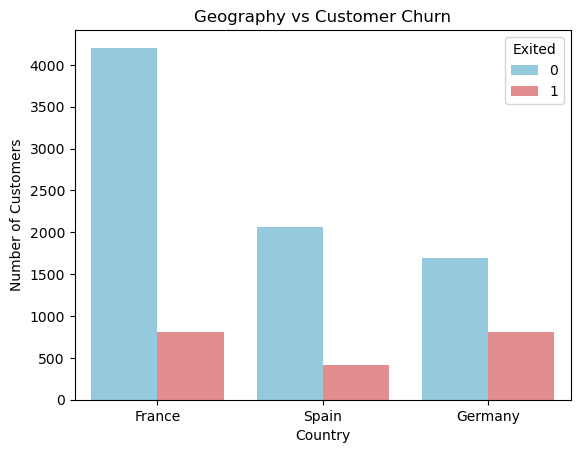

In [77]:
#Bar Chart - Compare churn across different countries.
sns.countplot(x='Geography', hue='Exited', data=df, palette=['skyblue', 'lightcoral'])
plt.title('Geography vs Customer Churn')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.show()

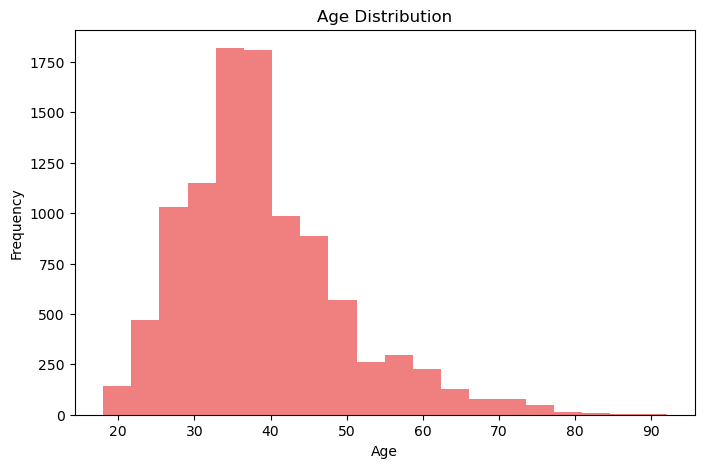

In [78]:
# Histogram - Understand the age distribution of customers.
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20, color='lightcoral')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

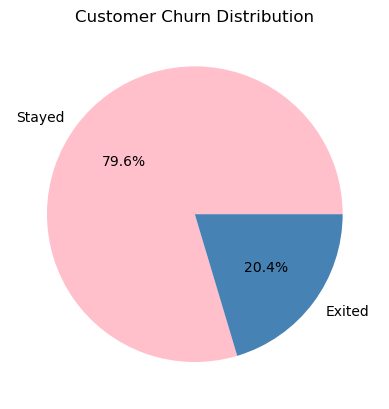

In [79]:
# Pie Chart - Show customer churn percentage.
df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Stayed','Exited'],
    colors=['pink', 'steelblue']
)

plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

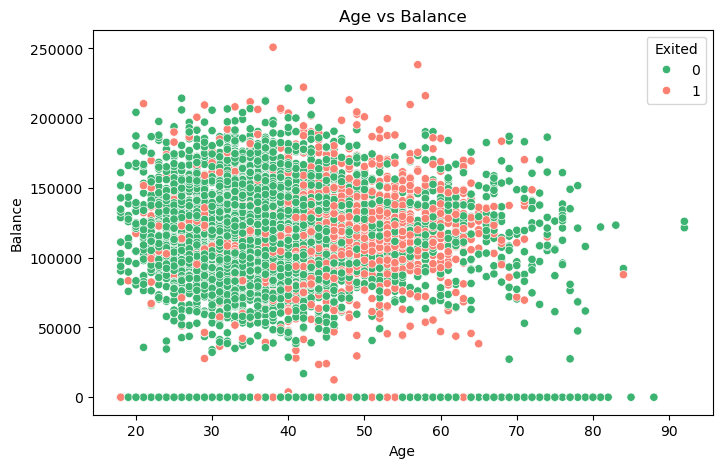

In [37]:
# Scatter Plot - Analyze the relationship between Age and Balance.
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Age',
    y='Balance',
    hue='Exited',
    data=df,
    palette=['mediumseagreen', 'salmon']
)

plt.title('Age vs Balance')
plt.show()

C:\Users\Kusuma\AppData\Local\Temp\ipykernel_24312\2104275371.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


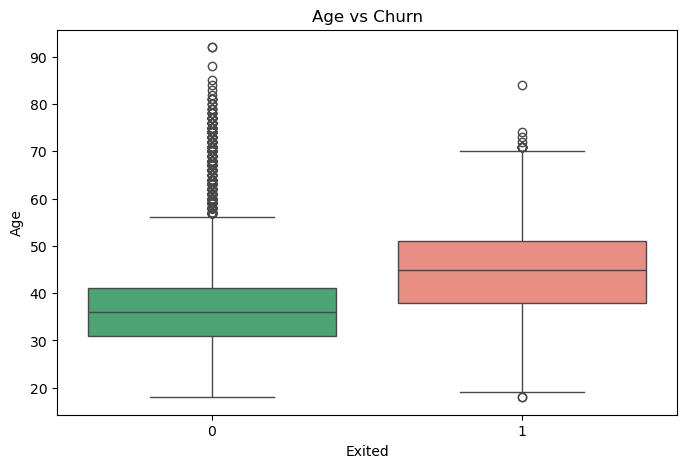

In [80]:
# Box Plot - Compare customer age between churned and retained customers.
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Exited',
    y='Age',
    data=df,
    palette=['mediumseagreen', 'salmon']
)

plt.title('Age vs Churn')
plt.show()

C:\Users\Kusuma\AppData\Local\Temp\ipykernel_24312\693633528.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100


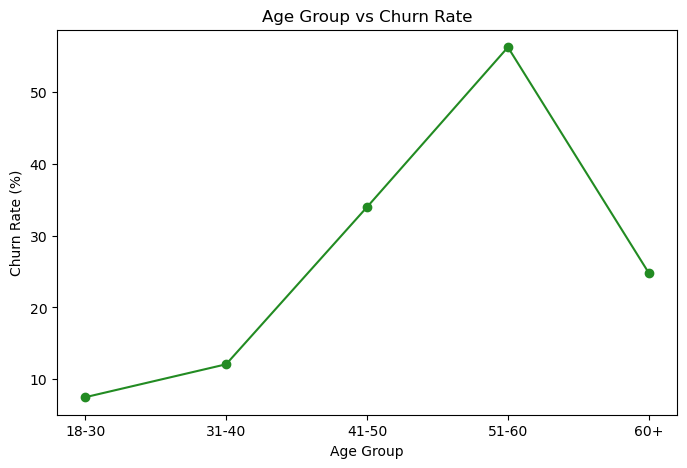

In [81]:
#Line Chart - Churn tends to increase with age.
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100

plt.figure(figsize=(8,5))

plt.plot(
    age_churn.index,
    age_churn.values,
    marker='o',
    color='forestgreen'
)

plt.title('Age Group vs Churn Rate')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.show()

### **Correlation Analysis**
 Correlation Analysis is a statistical technique used to measure the strength and direction of the relationship between two numerical variables.

In [82]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


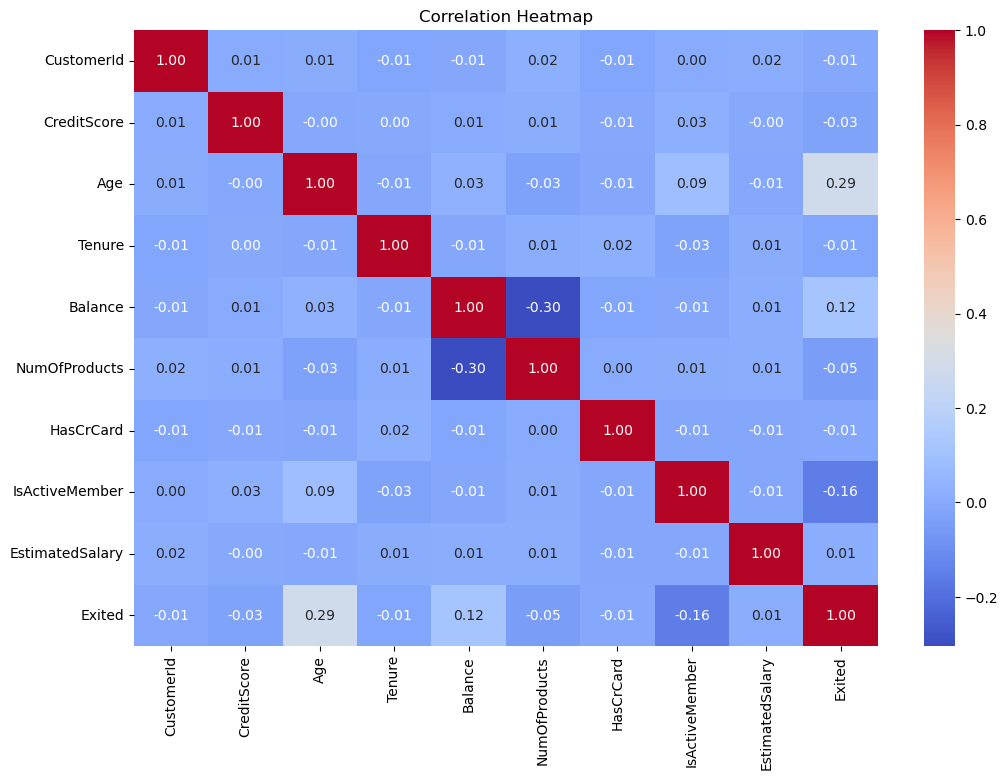

In [83]:
# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [75]:
# Factors Affecting Customer Churn(KPI)
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

| Factor         | Relationship with Churn | Business Action        |
| -------------- | ----------------------- | ---------------------- |
| Age            | Positive                | Retain older customers |
| IsActiveMember | Negative                | Increase engagement    |
| Balance        | Positive                | Offer premium benefits |
| NumOfProducts  | Negative                | Cross-sell products    |
| CreditScore    | Weak                    | Lower priority         |


### **Business Insights**

#### 1. Churn Distribution

**Observation:** Most customers stayed.
**Insight:** Churn rate is moderate.
**Business Impact:** Reducing churn increases revenue.

---

#### 2. Age Analysis

**Observation:** Older customers churn more.
**Insight:** Age affects customer retention.
**Business Impact:** Offer loyalty programs for older customers.

---

#### 3. Geography Analysis

**Observation:** Churn varies by country.
**Insight:** Customer behavior differs across regions.
**Business Impact:** Create region-specific strategies.

---

#### 4. Gender Analysis

**Observation:** Churn differs slightly by gender.
**Insight:** Preferences vary among customer groups.
**Business Impact:** Use targeted marketing campaigns.

---

#### 5. Active Member Analysis

**Observation:** Inactive customers churn more.
**Insight:** Engagement reduces churn.
**Business Impact:** Increase customer engagement.

---

#### 6. Number of Products Analysis

**Observation:** Customers with more products churn less.
**Insight:** Product usage increases loyalty.
**Business Impact:** Cross-sell banking products.

---

#### 7. Balance Analysis

**Observation:** High-balance customers churn more.
**Insight:** Valuable customers seek better offers.
**Business Impact:** Provide premium benefits.

---

#### 8. Correlation Analysis

**Observation:** Age, Activity, Balance, and Products affect churn.
**Insight:** Customer behavior drives churn.
**Business Impact:** Focus retention strategies on these factors.

---

#### Final Insight

**Observation:** Churn depends on age, activity, balance, and products.
**Insight:** Engaged customers are less likely to leave.
**Business Impact:** Improve engagement and offer personalized services.


## Problem-Solving Approach

#### Problem Statement

The bank is facing customer churn, where some customers leave the bank. This affects revenue and customer growth. The goal is to identify the factors causing customer churn and suggest ways to improve customer retention.

---

#### Analysis Approach

* Collected and understood the customer data.
* Cleaned the dataset by checking missing values and duplicates.
* Performed Exploratory Data Analysis (EDA).
* Analyzed customer behavior using visualizations, pivot tables, and groupby analysis.
* Conducted correlation analysis to identify factors affecting churn.

---

#### How Data Helps Solve the Problem

* Data reveals patterns in customer behavior.
* It helps identify which customers are more likely to leave.
* Factors such as age, activity status, balance, and number of products were found to influence churn.
* These insights help the bank make data-driven decisions to improve customer retention and reduce churn.

---

#### Conclusion

By analyzing customer data, the bank can identify high-risk customers and implement targeted retention strategies, leading to improved customer satisfaction and business growth.


### Final Recommendations

1. Increase customer engagement through mobile banking,
rewards programs, and personalized offers, as active members
show significantly lower churn rates.

2. Focus retention efforts on older customers, as churn tends
to be higher in higher age groups.

3. Encourage customers to use multiple banking products through
cross-selling strategies to improve customer loyalty.

4. Develop targeted retention campaigns for regions with higher
churn rates.

5. Monitor high-balance customers closely and provide premium
services to reduce the risk of losing valuable customers.

6. Regularly analyze customer behavior and feedback to identify
early signs of churn and take preventive actions.

## Final Conclusion

This project analyzed customer churn in the banking sector using Exploratory Data Analysis (EDA).

Key findings:
- Older customers are more likely to churn.
- Inactive customers have a significantly higher churn rate.
- Customers with higher account balances show higher churn tendencies.
- Customers using multiple bank products are less likely to leave.

By focusing on customer engagement, personalized services, and retention programs, banks can reduce churn and improve customer satisfaction.